In [5]:
import os

print("📊 Scanning Dataset Splitting (Train / Val / Test)...\n")

base_dir = r"D:\00_Thesis_Split"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# Get the list of disease classes
classes = sorted(os.listdir(train_dir))

total_train = 0
total_val = 0
total_test = 0

# Print the table header
print(f"{'Disease Class':<25} | {'Train':<6} | {'Val':<6} | {'Test':<6}")
print("-" * 53)

# Count and print the images for each class
for cls in classes:
    train_count = len(os.listdir(os.path.join(train_dir, cls)))
    val_count = len(os.listdir(os.path.join(val_dir, cls)))
    test_count = len(os.listdir(os.path.join(test_dir, cls)))
    
    total_train += train_count
    total_val += val_count
    total_test += test_count
    
    print(f"{cls:<25} | {train_count:<6} | {val_count:<6} | {test_count:<6}")

# Print the final totals
print("-" * 53)
print(f"{'TOTAL IMAGES':<25} | {total_train:<6} | {total_val:<6} | {total_test:<6}")
print(f"\n✅ Total Dataset Size: {total_train + total_val + total_test} images")

📊 Scanning Dataset Splitting (Train / Val / Test)...

Disease Class             | Train  | Val    | Test  
-----------------------------------------------------
potato_bacteria           | 455    | 56     | 58    
potato_early_blight       | 401    | 50     | 51    
potato_fungi              | 560    | 70     | 70    
potato_healthy            | 517    | 64     | 66    
potato_late_blight        | 231    | 28     | 30    
rice_blast                | 662    | 82     | 84    
rice_brown_spot           | 339    | 42     | 43    
rice_healthy              | 200    | 25     | 25    
rice_sheath_blight        | 400    | 50     | 50    
rice_tungro_virus         | 191    | 23     | 25    
wheat_black_point         | 242    | 30     | 31    
wheat_blast               | 320    | 40     | 40    
wheat_fusarium_foot_rot   | 200    | 25     | 25    
wheat_healthy             | 200    | 25     | 25    
wheat_leaf_blight         | 320    | 40     | 40    
--------------------------------------------

In [1]:
import os
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("⚙️ Initiating Final Thesis Pipeline Setup...\n")

# 1. Define Data Paths
train_dir = r"D:\00_Thesis_Split\train"
val_dir = r"D:\00_Thesis_Split\val"
test_dir = r"D:\00_Thesis_Split\test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 8 # Safe for GTX 1650!

# 2. CREATE THE NEW CLEAN FOLDER FOR MODELS
new_model_dir = r"D:\00_Thesis_Final_Models"
if not os.path.exists(new_model_dir):
    os.makedirs(new_model_dir)
print(f"📁 Dedicated Model Folder Ready: {new_model_dir}")

# 3. Calculate Exact Class Imbalance Weights
classes = sorted(os.listdir(train_dir))
image_counts = [len(os.listdir(os.path.join(train_dir, cls))) for cls in classes]
num_classes = len(classes)

weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.arange(num_classes), 
    y=np.repeat(np.arange(num_classes), image_counts)
)
pure_class_weights = {int(k): float(v) for k, v in dict(zip(np.arange(num_classes), weights)).items()}
print("⚖️ Imbalance weights mathematically locked.")

# 4. Initialize Real-Time Augmentation Engine
print("♻️ Spinning up Real-Time Augmentation Generators...")
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.1,   
    height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255) # STRICTLY NO AUGMENTATION

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True 
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False 
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False 
)
print("✅ Master Setup Complete. Ready to build models.")

⚙️ Initiating Final Thesis Pipeline Setup...

📁 Dedicated Model Folder Ready: D:\00_Thesis_Final_Models
⚖️ Imbalance weights mathematically locked.
♻️ Spinning up Real-Time Augmentation Generators...
Found 5238 images belonging to 15 classes.
Found 650 images belonging to 15 classes.
Found 663 images belonging to 15 classes.
✅ Master Setup Complete. Ready to build models.


In [7]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("🧠 Building Control Model: DenseNet121 (Phase 1 - Frozen Base)...")

# 1. Load DenseNet without the top layer
base_dense = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_dense.trainable = False # Freeze the brain!

# 2. Build Your Custom Head
x = base_dense.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions_dense = Dense(15, activation='softmax')(x)

model_dense = Model(inputs=base_dense.input, outputs=predictions_dense)

# 3. Compile
model_dense.compile(optimizer=Adam(learning_rate=0.001), 
                    loss='categorical_crossentropy', 
                    metrics=['accuracy'])

# 4. Callbacks (Saving to the NEW folder!)
filepath_dense_p1 = os.path.join(new_model_dir, "DenseNet121_Fresh_Phase1.h5")

checkpoint_dense = ModelCheckpoint(filepath_dense_p1, save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1)
early_stop_dense = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr_dense = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

# 5. Train Phase 1
print(f"\n🚀 Starting Training. Saving weights to: {filepath_dense_p1}")
history_dense_p1 = model_dense.fit(
    train_generator,
    epochs=15, 
    validation_data=val_generator,
    class_weight=pure_class_weights, 
    callbacks=[checkpoint_dense, early_stop_dense, reduce_lr_dense],
    verbose=1
)
print("\n✅ DenseNet121 Phase 1 Complete.")

🧠 Building Control Model: DenseNet121 (Phase 1 - Frozen Base)...

🚀 Starting Training. Saving weights to: D:\00_Thesis_Final_Models\DenseNet121_Fresh_Phase1.h5
Epoch 1/15
655/655 [==============================] - ETA: 0s - loss: 0.7515 - accuracy: 0.7291
Epoch 1: val_accuracy improved from -inf to 0.88923, saving model to D:\00_Thesis_Final_Models\DenseNet121_Fresh_Phase1.h5
655/655 [==============================] - 258s 375ms/step - loss: 0.7515 - accuracy: 0.7291 - val_loss: 0.3491 - val_accuracy: 0.8892 - lr: 0.0010
Epoch 2/15
655/655 [==============================] - ETA: 0s - loss: 0.4435 - accuracy: 0.8238
Epoch 2: val_accuracy did not improve from 0.88923
655/655 [==============================] - 155s 237ms/step - loss: 0.4435 - accuracy: 0.8238 - val_loss: 0.3757 - val_accuracy: 0.8862 - lr: 0.0010
Epoch 3/15
655/655 [==============================] - ETA: 0s - loss: 0.3863 - accuracy: 0.8511
Epoch 3: val_accuracy improved from 0.88923 to 0.92000, saving model to D:\00_Thes

In [8]:
print("⚡ Phase 2: Unfreezing DenseNet121 (Fine-Tuning)...")

# 1. Load the absolute best weights from Phase 1 (Epoch 14)
model_dense.load_weights(filepath_dense_p1)

# 2. UNFREEZE THE BASE
base_dense.trainable = True

# 3. Re-compile with a microscopic learning rate
model_dense.compile(optimizer=Adam(learning_rate=1e-5), 
                    loss='categorical_crossentropy', 
                    metrics=['accuracy'])

# 4. Setup Callbacks for Phase 2
filepath_dense_p2 = os.path.join(new_model_dir, "DenseNet121_Fresh_Phase2_FineTuned.h5")

checkpoint_dense_fine = ModelCheckpoint(
    filepath_dense_p2, 
    save_weights_only=True,
    save_best_only=True, 
    monitor='val_accuracy', 
    verbose=1
)

early_stop_dense_fine = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 5. Train the Unfrozen Model
print(f"\n🚀 Starting Fine-Tuning. Saving best weights to: {filepath_dense_p2}")
history_dense_p2 = model_dense.fit(
    train_generator,
    epochs=15, 
    validation_data=val_generator,
    class_weight=pure_class_weights, 
    callbacks=[checkpoint_dense_fine, early_stop_dense_fine],
    verbose=1
)

print("\n✅ DenseNet121 Phase 2 Fine-Tuning Complete.")

⚡ Phase 2: Unfreezing DenseNet121 (Fine-Tuning)...

🚀 Starting Fine-Tuning. Saving best weights to: D:\00_Thesis_Final_Models\DenseNet121_Fresh_Phase2_FineTuned.h5
Epoch 1/15
655/655 [==============================] - ETA: 0s - loss: 0.4555 - accuracy: 0.8274
Epoch 1: val_accuracy improved from -inf to 0.91538, saving model to D:\00_Thesis_Final_Models\DenseNet121_Fresh_Phase2_FineTuned.h5
655/655 [==============================] - 189s 251ms/step - loss: 0.4555 - accuracy: 0.8274 - val_loss: 0.2494 - val_accuracy: 0.9154
Epoch 2/15
655/655 [==============================] - ETA: 0s - loss: 0.2931 - accuracy: 0.8822
Epoch 2: val_accuracy improved from 0.91538 to 0.91846, saving model to D:\00_Thesis_Final_Models\DenseNet121_Fresh_Phase2_FineTuned.h5
655/655 [==============================] - 163s 249ms/step - loss: 0.2931 - accuracy: 0.8822 - val_loss: 0.2342 - val_accuracy: 0.9185
Epoch 3/15
655/655 [==============================] - ETA: 0s - loss: 0.2448 - accuracy: 0.8975
Epoch 3: 

📝 Initiating Final Exam & Visuals for Control Model (DenseNet121)...

📊 Running standard evaluation on unseen Test Set...
83/83 [==============================] - 19s 225ms/step - loss: 0.1437 - accuracy: 0.9502

🏆 Official DenseNet121 Baseline (Test Accuracy): 95.02%
🔍 Generating detailed predictions...
83/83 [==============================] - 17s 121ms/step

--- Thesis Documentation: DenseNet121 Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       0.96      0.93      0.95        58
    potato_early_blight       1.00      1.00      1.00        51
           potato_fungi       0.93      0.93      0.93        70
         potato_healthy       0.94      0.98      0.96        66
     potato_late_blight       1.00      0.97      0.98        30
             rice_blast       0.90      0.93      0.91        84
        rice_brown_spot       0.95      0.86      0.90        43
           rice_healthy       0.85      0.88      0.

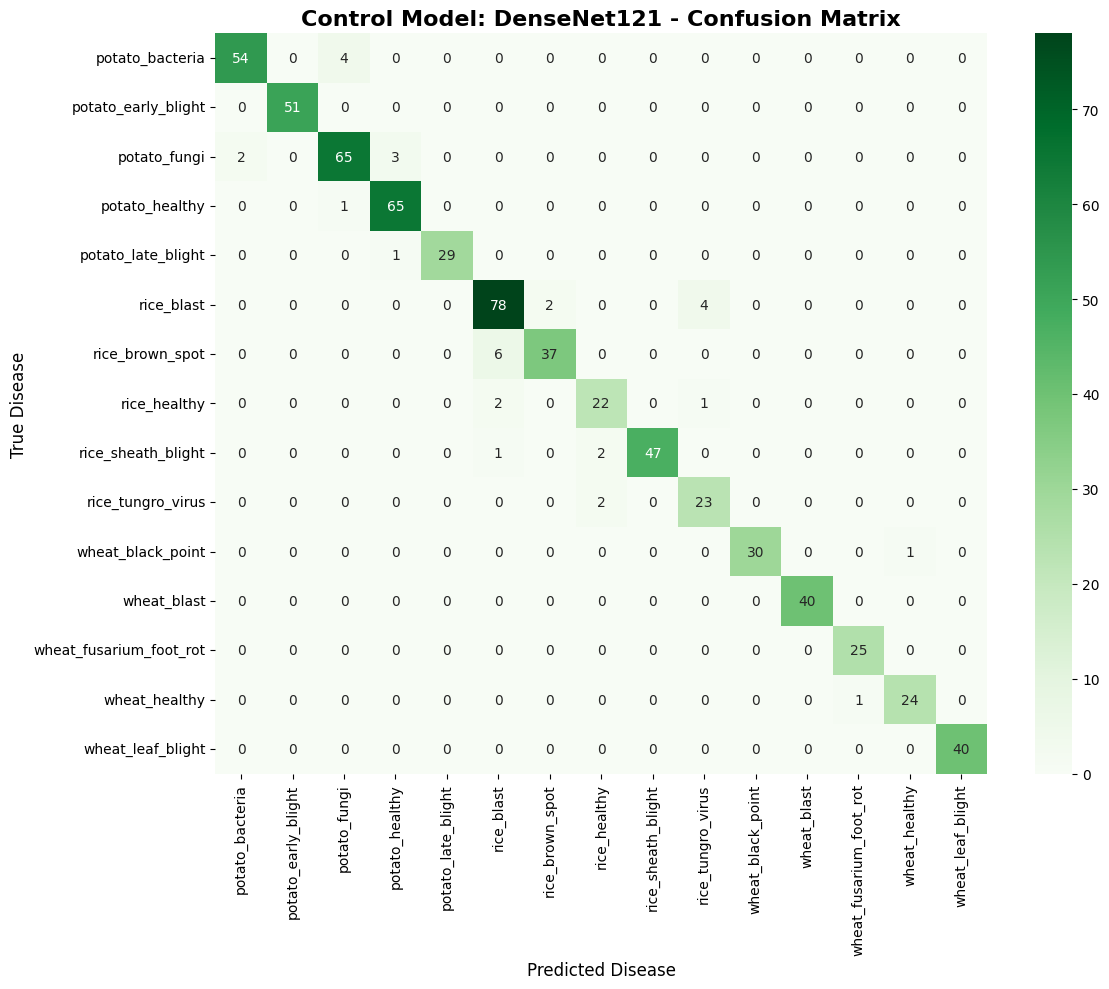

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

print("📝 Initiating Final Exam & Visuals for Control Model (DenseNet121)...")

# 1. Load the absolute best fine-tuned weights
filepath_dense_p2 = os.path.join(r"D:\00_Thesis_Final_Models", "DenseNet121_Fresh_Phase2_FineTuned.h5")
model_dense.load_weights(filepath_dense_p2)

# 2. Get overall Accuracy on the locked-away test set
print("\n📊 Running standard evaluation on unseen Test Set...")
test_loss_dense, test_acc_dense = model_dense.evaluate(test_generator, verbose=1)
print(f"\n🏆 Official DenseNet121 Baseline (Test Accuracy): {test_acc_dense * 100:.2f}%")

# 3. Generate Predictions for the Detailed Report
print("🔍 Generating detailed predictions...")
predictions_dense = model_dense.predict(test_generator, verbose=1)
y_pred_dense = np.argmax(predictions_dense, axis=1)
y_true_dense = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 4. Print Classification Report
print("\n--- Thesis Documentation: DenseNet121 Classification Report ---")
print(classification_report(y_true_dense, y_pred_dense, target_names=class_names))

# 5. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm_dense = confusion_matrix(y_true_dense, y_pred_dense)
# Using a Green color map for the Control Model
sns.heatmap(cm_dense, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Control Model: DenseNet121 - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save to the new, clean folder
cm_path = os.path.join(r"D:\00_Thesis_Final_Models", "DenseNet121_Fresh_Confusion_Matrix.png")
plt.savefig(cm_path)
print(f"✅ Confusion Matrix saved to {cm_path}")
plt.show()

In [10]:
import os
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("🧹 Clearing GPU VRAM for Model #2...")
tf.keras.backend.clear_session()

new_model_dir = r"D:\00_Thesis_Final_Models"

# ==========================================
# PHASE 1: FROZEN BASE
# ==========================================
print("\n🧠 Building Control Model: MobileNetV2 (Phase 1 - Frozen Base)...")

base_mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_mobile.trainable = False 

x = base_mobile.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions_mobile = Dense(15, activation='softmax')(x)

model_mobile = Model(inputs=base_mobile.input, outputs=predictions_mobile)

model_mobile.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

filepath_mob_p1 = os.path.join(new_model_dir, "MobileNetV2_Fresh_Phase1.h5")
checkpoint_mob = ModelCheckpoint(filepath_mob_p1, save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1)
early_stop_mob = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr_mob = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

print(f"🚀 Starting Phase 1 Training. Saving to: {filepath_mob_p1}")
history_mob_p1 = model_mobile.fit(
    train_generator, epochs=15, validation_data=val_generator,
    class_weight=pure_class_weights, callbacks=[checkpoint_mob, early_stop_mob, reduce_lr_mob], verbose=1
)

# ==========================================
# PHASE 2: FINE-TUNING
# ==========================================
print("\n⚡ Phase 2: Unfreezing MobileNetV2 (Fine-Tuning)...")

# Load best weights from Phase 1, then unfreeze
model_mobile.load_weights(filepath_mob_p1)
base_mobile.trainable = True

model_mobile.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

filepath_mob_p2 = os.path.join(new_model_dir, "MobileNetV2_Fresh_Phase2_FineTuned.h5")
checkpoint_mob_fine = ModelCheckpoint(filepath_mob_p2, save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1)
early_stop_mob_fine = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print(f"🚀 Starting Fine-Tuning. Saving best weights to: {filepath_mob_p2}")
history_mob_p2 = model_mobile.fit(
    train_generator, epochs=15, validation_data=val_generator,
    class_weight=pure_class_weights, callbacks=[checkpoint_mob_fine, early_stop_mob_fine], verbose=1
)

print("\n✅ MobileNetV2 Full Training Complete.")

🧹 Clearing GPU VRAM for Model #2...

🧠 Building Control Model: MobileNetV2 (Phase 1 - Frozen Base)...
🚀 Starting Phase 1 Training. Saving to: D:\00_Thesis_Final_Models\MobileNetV2_Fresh_Phase1.h5
Epoch 1/15
655/655 [==============================] - ETA: 0s - loss: 1.0010 - accuracy: 0.6938
Epoch 1: val_accuracy improved from -inf to 0.82308, saving model to D:\00_Thesis_Final_Models\MobileNetV2_Fresh_Phase1.h5
655/655 [==============================] - 163s 242ms/step - loss: 1.0010 - accuracy: 0.6938 - val_loss: 0.5775 - val_accuracy: 0.8231 - lr: 0.0010
Epoch 2/15
655/655 [==============================] - ETA: 0s - loss: 0.6341 - accuracy: 0.7931
Epoch 2: val_accuracy improved from 0.82308 to 0.87077, saving model to D:\00_Thesis_Final_Models\MobileNetV2_Fresh_Phase1.h5
655/655 [==============================] - 154s 235ms/step - loss: 0.6341 - accuracy: 0.7931 - val_loss: 0.4471 - val_accuracy: 0.8708 - lr: 0.0010
Epoch 3/15
655/655 [==============================] - ETA: 0s - los

📝 Initiating Final Exam & Visuals for Control Model (MobileNetV2)...

📊 Running standard evaluation on unseen Test Set...
83/83 [==============================] - 10s 121ms/step - loss: 0.2954 - accuracy: 0.9186

🏆 Official MobileNetV2 Baseline (Test Accuracy): 91.86%
🔍 Generating detailed predictions...
83/83 [==============================] - 12s 122ms/step

--- Thesis Documentation: MobileNetV2 Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       0.96      0.95      0.96        58
    potato_early_blight       1.00      1.00      1.00        51
           potato_fungi       0.93      0.90      0.91        70
         potato_healthy       0.91      0.95      0.93        66
     potato_late_blight       0.97      0.97      0.97        30
             rice_blast       0.89      0.75      0.81        84
        rice_brown_spot       0.88      0.84      0.86        43
           rice_healthy       0.63      0.88      0.

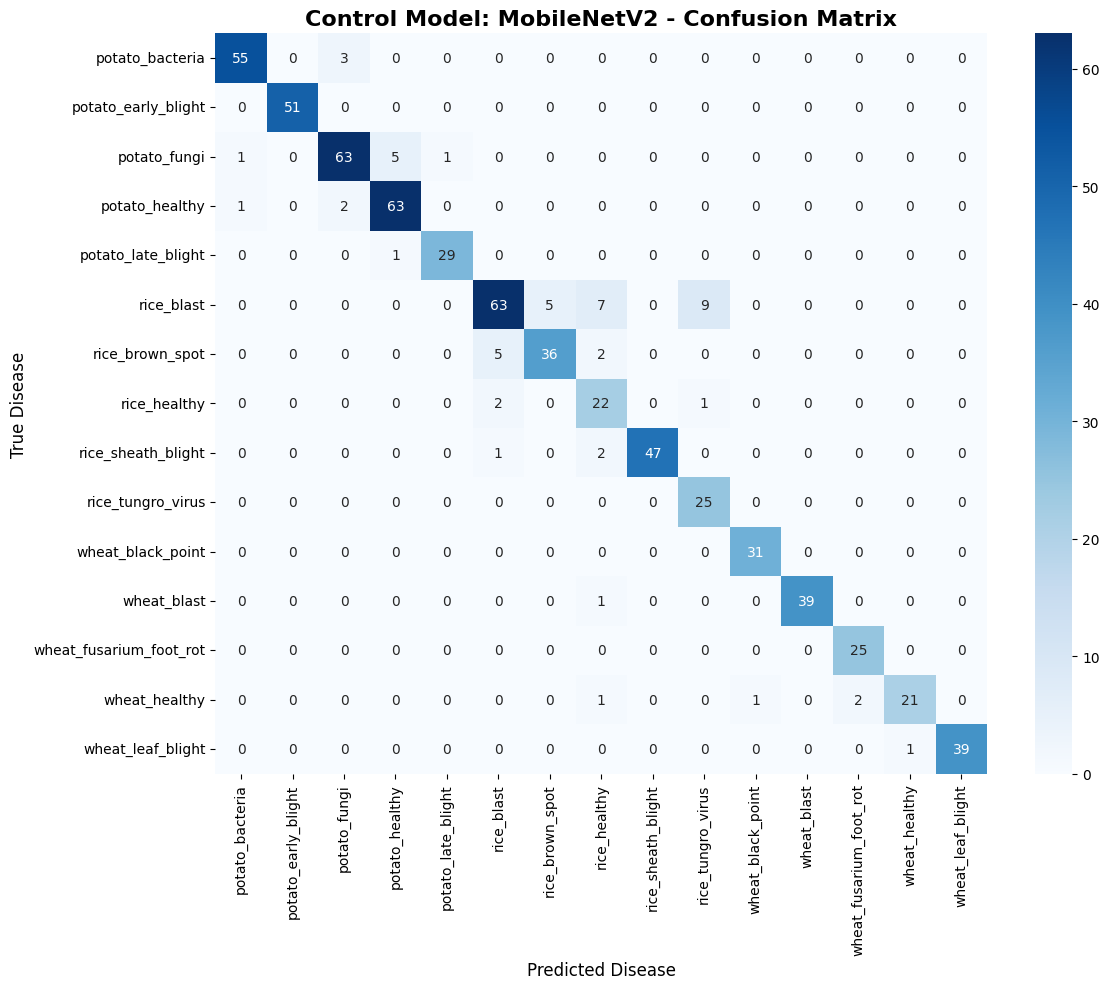

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

print("📝 Initiating Final Exam & Visuals for Control Model (MobileNetV2)...")

# 1. Load the absolute best fine-tuned weights
filepath_mob_p2 = os.path.join(r"D:\00_Thesis_Final_Models", "MobileNetV2_Fresh_Phase2_FineTuned.h5")
model_mobile.load_weights(filepath_mob_p2)

# 2. Get overall Accuracy on the locked-away test set
print("\n📊 Running standard evaluation on unseen Test Set...")
test_loss_mob, test_acc_mob = model_mobile.evaluate(test_generator, verbose=1)
print(f"\n🏆 Official MobileNetV2 Baseline (Test Accuracy): {test_acc_mob * 100:.2f}%")

# 3. Generate Predictions for the Detailed Report
print("🔍 Generating detailed predictions...")
predictions_mob = model_mobile.predict(test_generator, verbose=1)
y_pred_mob = np.argmax(predictions_mob, axis=1)
y_true_mob = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 4. Print Classification Report
print("\n--- Thesis Documentation: MobileNetV2 Classification Report ---")
print(classification_report(y_true_mob, y_pred_mob, target_names=class_names))

# 5. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm_mob = confusion_matrix(y_true_mob, y_pred_mob)
# Using a Blue color map for MobileNet
sns.heatmap(cm_mob, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Control Model: MobileNetV2 - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save to the new, clean folder
cm_path_mob = os.path.join(r"D:\00_Thesis_Final_Models", "MobileNetV2_Fresh_Confusion_Matrix.png")
plt.savefig(cm_path_mob)
print(f"✅ Confusion Matrix saved to {cm_path_mob}")
plt.show()

In [12]:
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("🧹 Clearing GPU VRAM for Model #3...")
tf.keras.backend.clear_session()

new_model_dir = r"D:\00_Thesis_Final_Models"

# ==========================================
# PHASE 1: FROZEN BASE
# ==========================================
print("\n🧠 Building Control Model: EfficientNetB0 (Phase 1 - Frozen Base)...")

base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_eff.trainable = False 

x = base_eff.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions_eff = Dense(15, activation='softmax')(x)

model_eff = Model(inputs=base_eff.input, outputs=predictions_eff)

model_eff.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

filepath_eff_p1 = os.path.join(new_model_dir, "EfficientNetB0_Fresh_Phase1.h5")
checkpoint_eff = ModelCheckpoint(filepath_eff_p1, save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1)
early_stop_eff = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr_eff = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

print(f"🚀 Starting Phase 1 Training. Saving to: {filepath_eff_p1}")
history_eff_p1 = model_eff.fit(
    train_generator, epochs=15, validation_data=val_generator,
    class_weight=pure_class_weights, callbacks=[checkpoint_eff, early_stop_eff, reduce_lr_eff], verbose=1
)

# ==========================================
# PHASE 2: FINE-TUNING
# ==========================================
print("\n⚡ Phase 2: Unfreezing EfficientNetB0 (Fine-Tuning)...")

# Load best weights from Phase 1, then unfreeze
model_eff.load_weights(filepath_eff_p1)
base_eff.trainable = True

model_eff.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

filepath_eff_p2 = os.path.join(new_model_dir, "EfficientNetB0_Fresh_Phase2_FineTuned.h5")
checkpoint_eff_fine = ModelCheckpoint(filepath_eff_p2, save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1)
early_stop_eff_fine = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print(f"🚀 Starting Fine-Tuning. Saving best weights to: {filepath_eff_p2}")
history_eff_p2 = model_eff.fit(
    train_generator, epochs=15, validation_data=val_generator,
    class_weight=pure_class_weights, callbacks=[checkpoint_eff_fine, early_stop_eff_fine], verbose=1
)

print("\n✅ EfficientNetB0 Full Training Complete.")

🧹 Clearing GPU VRAM for Model #3...

🧠 Building Control Model: EfficientNetB0 (Phase 1 - Frozen Base)...
🚀 Starting Phase 1 Training. Saving to: D:\00_Thesis_Final_Models\EfficientNetB0_Fresh_Phase1.h5
Epoch 1/15
655/655 [==============================] - ETA: 0s - loss: 3.3071 - accuracy: 0.0777
Epoch 1: val_accuracy improved from -inf to 0.03846, saving model to D:\00_Thesis_Final_Models\EfficientNetB0_Fresh_Phase1.h5
655/655 [==============================] - 170s 247ms/step - loss: 3.3071 - accuracy: 0.0777 - val_loss: 2.7105 - val_accuracy: 0.0385 - lr: 0.0010
Epoch 2/15
655/655 [==============================] - ETA: 0s - loss: 2.7943 - accuracy: 0.0693
Epoch 2: val_accuracy improved from 0.03846 to 0.08154, saving model to D:\00_Thesis_Final_Models\EfficientNetB0_Fresh_Phase1.h5
655/655 [==============================] - 156s 237ms/step - loss: 2.7943 - accuracy: 0.0693 - val_loss: 2.7013 - val_accuracy: 0.0815 - lr: 0.0010
Epoch 3/15
655/655 [==============================] - E

📝 Initiating Final Exam & Visuals for Control Model (EfficientNetB0)...

📊 Running standard evaluation on unseen Test Set...
83/83 [==============================] - 20s 227ms/step - loss: 0.6198 - accuracy: 0.7858

🏆 Official EfficientNetB0 Baseline (Test Accuracy): 78.58%
🔍 Generating detailed predictions...
83/83 [==============================] - 14s 112ms/step

--- Thesis Documentation: EfficientNetB0 Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       0.95      0.69      0.80        58
    potato_early_blight       0.96      1.00      0.98        51
           potato_fungi       0.74      0.81      0.78        70
         potato_healthy       0.84      0.89      0.87        66
     potato_late_blight       1.00      0.93      0.97        30
             rice_blast       0.72      0.43      0.54        84
        rice_brown_spot       0.52      0.84      0.64        43
           rice_healthy       0.55      0.6

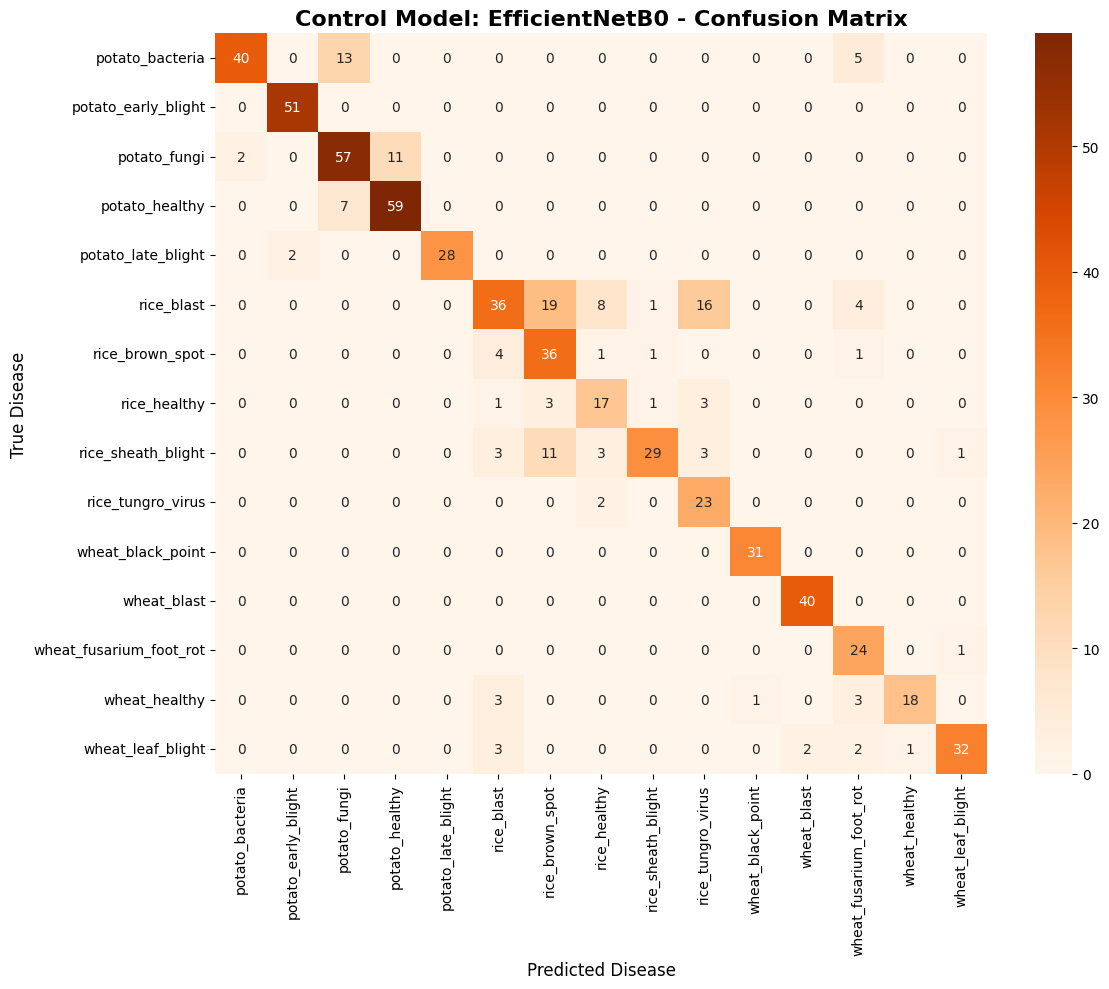

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

print("📝 Initiating Final Exam & Visuals for Control Model (EfficientNetB0)...")

# 1. Load the absolute best fine-tuned weights
filepath_eff_p2 = os.path.join(r"D:\00_Thesis_Final_Models", "EfficientNetB0_Fresh_Phase2_FineTuned.h5")
model_eff.load_weights(filepath_eff_p2)

# 2. Get overall Accuracy on the locked-away test set
print("\n📊 Running standard evaluation on unseen Test Set...")
test_loss_eff, test_acc_eff = model_eff.evaluate(test_generator, verbose=1)
print(f"\n🏆 Official EfficientNetB0 Baseline (Test Accuracy): {test_acc_eff * 100:.2f}%")

# 3. Generate Predictions for the Detailed Report
print("🔍 Generating detailed predictions...")
predictions_eff = model_eff.predict(test_generator, verbose=1)
y_pred_eff = np.argmax(predictions_eff, axis=1)
y_true_eff = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 4. Print Classification Report
print("\n--- Thesis Documentation: EfficientNetB0 Classification Report ---")
print(classification_report(y_true_eff, y_pred_eff, target_names=class_names))

# 5. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm_eff = confusion_matrix(y_true_eff, y_pred_eff)
# Using an Orange color map for EfficientNet
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Control Model: EfficientNetB0 - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save to the new, clean folder
cm_path_eff = os.path.join(r"D:\00_Thesis_Final_Models", "EfficientNetB0_Fresh_Confusion_Matrix.png")
plt.savefig(cm_path_eff)
print(f"✅ Confusion Matrix saved to {cm_path_eff}")
plt.show()

In [14]:
import os
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, MobileNetV2
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("🧹 Clearing GPU VRAM for Hybrid 1...")
tf.keras.backend.clear_session()

new_model_dir = r"D:\00_Thesis_Final_Models"

# ==========================================
# PHASE 1: BUILD & TRAIN FROZEN HYBRID
# ==========================================
print("\n🧬 Building Hybrid 1: DenseNet121 + MobileNetV2 (Phase 1)...")

shared_input = Input(shape=(224, 224, 3), name="hybrid1_input")

# Brain 1: DenseNet121
base_dense = DenseNet121(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_dense.layers: layer._name = layer.name + str("_dense")
base_dense.trainable = False
features_dense = GlobalAveragePooling2D()(base_dense.output)

# Brain 2: MobileNetV2
base_mob = MobileNetV2(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_mob.layers: layer._name = layer.name + str("_mob")
base_mob.trainable = False
features_mob = GlobalAveragePooling2D()(base_mob.output)

# FUSION
combined_features = Concatenate(name="feature_fusion_1")([features_dense, features_mob])

# Master Head
x = BatchNormalization()(combined_features)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
hybrid_preds_1 = Dense(15, activation='softmax', name="final_output_1")(x)

hybrid_model_1 = Model(inputs=shared_input, outputs=hybrid_preds_1)
hybrid_model_1.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

filepath_hyb1_p1 = os.path.join(new_model_dir, "Hybrid1_Fresh_Phase1.h5")
checkpoint_hyb1 = ModelCheckpoint(filepath_hyb1_p1, save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1)
early_stop_hyb1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr_hyb1 = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

print(f"🚀 Starting Phase 1 Training. Saving to: {filepath_hyb1_p1}")
history_hyb1_p1 = hybrid_model_1.fit(
    train_generator, epochs=15, validation_data=val_generator,
    class_weight=pure_class_weights, callbacks=[checkpoint_hyb1, early_stop_hyb1, reduce_lr_hyb1], verbose=1
)

# ==========================================
# PHASE 2: FINE-TUNING THE HYBRID
# ==========================================
print("\n⚡ Phase 2: Unfreezing Hybrid 1 (Fine-Tuning)...")

hybrid_model_1.load_weights(filepath_hyb1_p1)
base_dense.trainable = True
base_mob.trainable = True

hybrid_model_1.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

filepath_hyb1_p2 = os.path.join(new_model_dir, "Hybrid1_Fresh_Phase2_FineTuned.h5")
checkpoint_hyb1_fine = ModelCheckpoint(filepath_hyb1_p2, save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1)
early_stop_hyb1_fine = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print(f"🚀 Starting Fine-Tuning. Saving best weights to: {filepath_hyb1_p2}")
history_hyb1_p2 = hybrid_model_1.fit(
    train_generator, epochs=15, validation_data=val_generator,
    class_weight=pure_class_weights, callbacks=[checkpoint_hyb1_fine, early_stop_hyb1_fine], verbose=1
)

print("\n✅ Hybrid 1 Full Training Complete.")

🧹 Clearing GPU VRAM for Hybrid 1...

🧬 Building Hybrid 1: DenseNet121 + MobileNetV2 (Phase 1)...
🚀 Starting Phase 1 Training. Saving to: D:\00_Thesis_Final_Models\Hybrid1_Fresh_Phase1.h5
Epoch 1/15
655/655 [==============================] - ETA: 0s - loss: 1.1652 - accuracy: 0.6573
Epoch 1: val_accuracy improved from -inf to 0.83077, saving model to D:\00_Thesis_Final_Models\Hybrid1_Fresh_Phase1.h5
655/655 [==============================] - 186s 265ms/step - loss: 1.1652 - accuracy: 0.6573 - val_loss: 0.4612 - val_accuracy: 0.8308 - lr: 0.0010
Epoch 2/15
655/655 [==============================] - ETA: 0s - loss: 0.6987 - accuracy: 0.7663
Epoch 2: val_accuracy improved from 0.83077 to 0.85692, saving model to D:\00_Thesis_Final_Models\Hybrid1_Fresh_Phase1.h5
655/655 [==============================] - 162s 247ms/step - loss: 0.6987 - accuracy: 0.7663 - val_loss: 0.4479 - val_accuracy: 0.8569 - lr: 0.0010
Epoch 3/15
655/655 [==============================] - ETA: 0s - loss: 0.5356 - accur

ResourceExhaustedError: Graph execution error:

Detected at node 'gradient_tape/model/block_1_depthwise_mob/depthwise/DepthwiseConv2dNativeBackpropInput' defined at (most recent call last):
    File "c:\Users\shiha\miniconda3\envs\tf_gpu\lib\runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "c:\Users\shiha\miniconda3\envs\tf_gpu\lib\runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "c:\Users\shiha\miniconda3\envs\tf_gpu\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "c:\Users\shiha\miniconda3\envs\tf_gpu\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "c:\Users\shiha\miniconda3\envs\tf_gpu\lib\site-packages\ipykernel\kernelapp.py", line 739, in start
      self.io_loop.start()
    File "c:\Users\shiha\miniconda3\envs\tf_gpu\lib\site-packages\tornado\platform\asyncio.py", line 211, in start
      s

In [15]:
import os
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, MobileNetV2
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("🧹 1. Sledgehammering GPU Memory to clear the crash...")
tf.keras.backend.clear_session()

new_model_dir = r"D:\00_Thesis_Final_Models"

# ==========================================
# REBUILD GENERATORS WITH BATCH SIZE 4
# ==========================================
print("♻️ 2. Rebuilding Generators with Ultra-Safe Batch Size 4...")
train_dir = r"D:\00_Thesis_Split\train"
val_dir = r"D:\00_Thesis_Split\val"
IMG_SIZE = (224, 224)
SAFE_BATCH_SIZE = 4  # <--- The fix!

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.1,   
    height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=SAFE_BATCH_SIZE, class_mode='categorical', shuffle=True 
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=SAFE_BATCH_SIZE, class_mode='categorical', shuffle=False 
)

# ==========================================
# REBUILD HYBRID 1 ARCHITECTURE
# ==========================================
print("🧬 3. Rebuilding Hybrid 1 Architecture...")
shared_input = Input(shape=(224, 224, 3), name="hybrid1_input")

base_dense = DenseNet121(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_dense.layers: layer._name = layer.name + str("_dense")
features_dense = GlobalAveragePooling2D()(base_dense.output)

base_mob = MobileNetV2(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_mob.layers: layer._name = layer.name + str("_mob")
features_mob = GlobalAveragePooling2D()(base_mob.output)

combined_features = Concatenate(name="feature_fusion_1")([features_dense, features_mob])

x = BatchNormalization()(combined_features)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
hybrid_preds_1 = Dense(15, activation='softmax', name="final_output_1")(x)

hybrid_model_1 = Model(inputs=shared_input, outputs=hybrid_preds_1)

# ==========================================
# RESUME PHASE 2: FINE-TUNING
# ==========================================
print("🧠 4. Loading saved Phase 1 weights and Unfreezing...")
hybrid_model_1.load_weights(os.path.join(new_model_dir, "Hybrid1_Fresh_Phase1.h5"))

# Unfreeze both!
base_dense.trainable = True
base_mob.trainable = True

hybrid_model_1.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

filepath_hyb1_p2 = os.path.join(new_model_dir, "Hybrid1_Fresh_Phase2_FineTuned.h5")
checkpoint_hyb1_fine = ModelCheckpoint(filepath_hyb1_p2, save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1)
early_stop_hyb1_fine = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print(f"\n🚀 Resuming Fine-Tuning (Phase 2). Saving best weights to: {filepath_hyb1_p2}")
history_hyb1_p2 = hybrid_model_1.fit(
    train_generator, epochs=15, validation_data=val_generator,
    class_weight=pure_class_weights, callbacks=[checkpoint_hyb1_fine, early_stop_hyb1_fine], verbose=1
)

print("\n✅ Hybrid 1 Full Training Complete.")

🧹 1. Sledgehammering GPU Memory to clear the crash...
♻️ 2. Rebuilding Generators with Ultra-Safe Batch Size 4...
Found 5238 images belonging to 15 classes.
Found 650 images belonging to 15 classes.
🧬 3. Rebuilding Hybrid 1 Architecture...
🧠 4. Loading saved Phase 1 weights and Unfreezing...

🚀 Resuming Fine-Tuning (Phase 2). Saving best weights to: D:\00_Thesis_Final_Models\Hybrid1_Fresh_Phase2_FineTuned.h5
Epoch 1/15
1310/1310 [==============================] - ETA: 0s - loss: 1.0081 - accuracy: 0.6926
Epoch 1: val_accuracy improved from -inf to 0.88154, saving model to D:\00_Thesis_Final_Models\Hybrid1_Fresh_Phase2_FineTuned.h5
1310/1310 [==============================] - 266s 176ms/step - loss: 1.0081 - accuracy: 0.6926 - val_loss: 0.3903 - val_accuracy: 0.8815
Epoch 2/15
1310/1310 [==============================] - ETA: 0s - loss: 0.7519 - accuracy: 0.7549
Epoch 2: val_accuracy improved from 0.88154 to 0.88923, saving model to D:\00_Thesis_Final_Models\Hybrid1_Fresh_Phase2_FineTun

📝 Initiating Final Exam & Visuals for Hybrid 1 (DenseNet121 + MobileNetV2)...
Found 663 images belonging to 15 classes.

📊 Running standard evaluation on unseen Test Set...
166/166 [==============================] - 22s 130ms/step - loss: 0.2946 - accuracy: 0.9110

🏆 Official Hybrid 1 Baseline (Test Accuracy): 91.10%
🔍 Generating detailed predictions...
166/166 [==============================] - 20s 74ms/step

--- Thesis Documentation: Hybrid 1 Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       0.92      0.95      0.93        58
    potato_early_blight       1.00      1.00      1.00        51
           potato_fungi       0.95      0.87      0.91        70
         potato_healthy       0.92      0.98      0.95        66
     potato_late_blight       1.00      0.97      0.98        30
             rice_blast       0.86      0.68      0.76        84
        rice_brown_spot       0.83      0.81      0.82        43
    

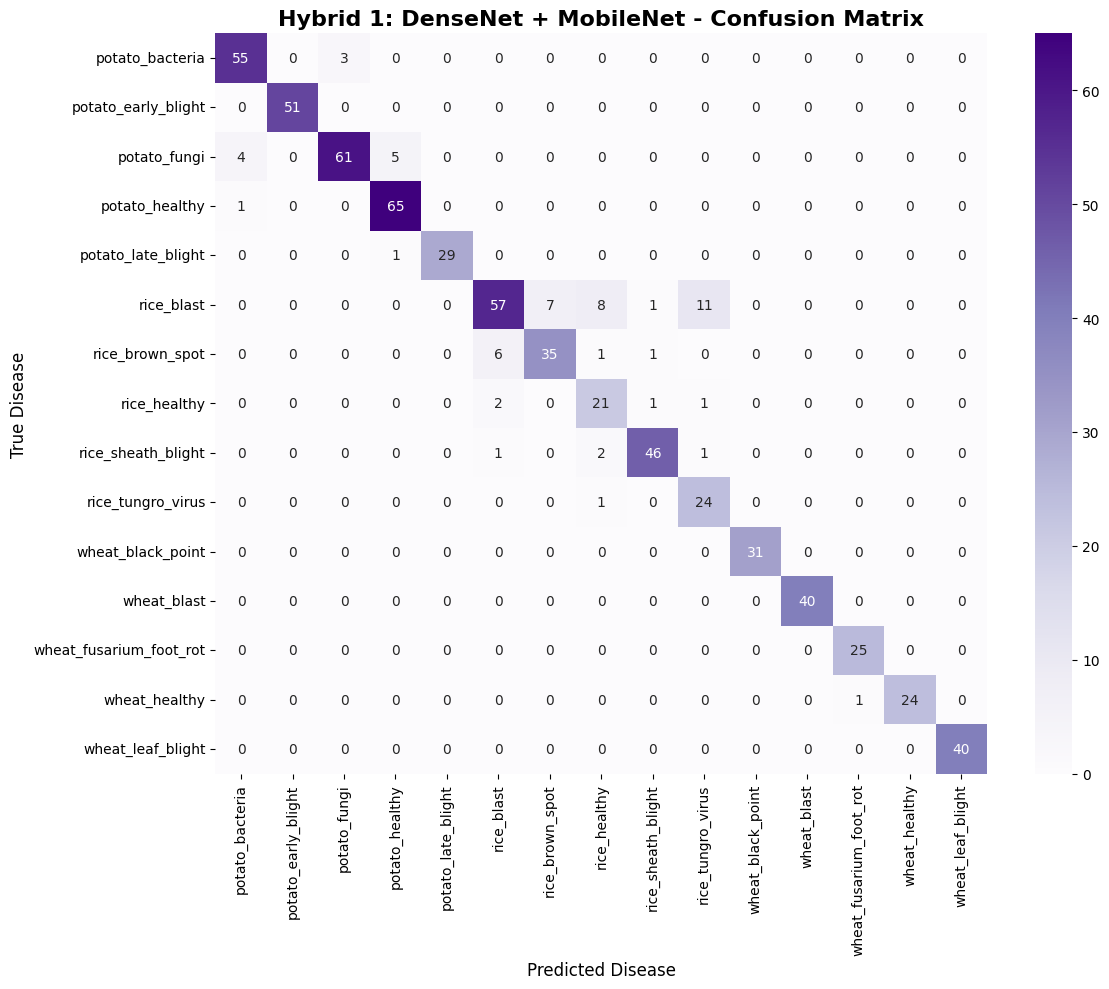

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

print("📝 Initiating Final Exam & Visuals for Hybrid 1 (DenseNet121 + MobileNetV2)...")

# 1. Rebuild Test Generator with Batch Size 4
test_dir = r"D:\00_Thesis_Split\test"
IMG_SIZE = (224, 224)
TEST_BATCH_SIZE = 4 

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=TEST_BATCH_SIZE, class_mode='categorical', shuffle=False 
)

# 2. Load the absolute best fine-tuned weights
filepath_hyb1_p2 = os.path.join(r"D:\00_Thesis_Final_Models", "Hybrid1_Fresh_Phase2_FineTuned.h5")
hybrid_model_1.load_weights(filepath_hyb1_p2)
# 2. Load the absolute best fine-tuned weights for Hybrid 2
filepath_hyb2_p2 = os.path.join(r"D:\00_Thesis_Final_Models", "Hybrid2_Fresh_Phase2_FineTuned.h5")
hybrid_model_2.load_weights(filepath_hyb2_p2)


# 3. Get overall Accuracy on the locked-away test set
print("\n📊 Running standard evaluation on unseen Test Set...")
test_loss_hyb1, test_acc_hyb1 = hybrid_model_1.evaluate(test_generator, verbose=1)
print(f"\n🏆 Official Hybrid 1 Baseline (Test Accuracy): {test_acc_hyb1 * 100:.2f}%")

# 4. Generate Predictions for the Detailed Report
print("🔍 Generating detailed predictions...")
predictions_hyb1 = hybrid_model_1.predict(test_generator, verbose=1)
y_pred_hyb1 = np.argmax(predictions_hyb1, axis=1)
y_true_hyb1 = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 5. Print Classification Report
print("\n--- Thesis Documentation: Hybrid 1 Classification Report ---")
print(classification_report(y_true_hyb1, y_pred_hyb1, target_names=class_names))

# 6. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm_hyb1 = confusion_matrix(y_true_hyb1, y_pred_hyb1)
# Using a Purple color map to distinguish Hybrids from Control Models
sns.heatmap(cm_hyb1, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title('Hybrid 1: DenseNet + MobileNet - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save to the new, clean folder
cm_path_hyb1 = os.path.join(r"D:\00_Thesis_Final_Models", "Hybrid1_Fresh_Confusion_Matrix.png")
plt.savefig(cm_path_hyb1)
print(f"✅ Confusion Matrix saved to {cm_path_hyb1}")
plt.show()

In [2]:
import os
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, MobileNetV2
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("🧹 1. Sledgehammering GPU Memory for Attempt 2...")
tf.keras.backend.clear_session()

new_model_dir = r"D:\00_Thesis_Final_Models"

# ==========================================
# REBUILD GENERATORS (SAFE BATCH SIZE 4)
# ==========================================
print("♻️ 2. Spinning up Generators (Batch Size 4)...")
train_dir = r"D:\00_Thesis_Split\train"
val_dir = r"D:\00_Thesis_Split\val"
IMG_SIZE = (224, 224)
SAFE_BATCH_SIZE = 4 

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.1,   
    height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=SAFE_BATCH_SIZE, class_mode='categorical', shuffle=True 
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=SAFE_BATCH_SIZE, class_mode='categorical', shuffle=False 
)

# ==========================================
# PHASE 1: BUILD & TRAIN FROZEN HYBRID
# ==========================================
print("\n🧬 3. Building Hybrid 1 Architecture...")

shared_input = Input(shape=(224, 224, 3), name="hybrid1_input")

# Brain 1: DenseNet121
base_dense = DenseNet121(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_dense.layers: layer._name = layer.name + str("_dense")
base_dense.trainable = False
features_dense = GlobalAveragePooling2D()(base_dense.output)

# Brain 2: MobileNetV2
base_mob = MobileNetV2(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_mob.layers: layer._name = layer.name + str("_mob")
base_mob.trainable = False
features_mob = GlobalAveragePooling2D()(base_mob.output)

# FUSION
combined_features = Concatenate(name="feature_fusion_1")([features_dense, features_mob])

# Master Head
x = BatchNormalization()(combined_features)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
hybrid_preds_1 = Dense(15, activation='softmax', name="final_output_1")(x)

hybrid_model_1 = Model(inputs=shared_input, outputs=hybrid_preds_1)
hybrid_model_1.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Using "_Attempt2" to keep files safe!
filepath_hyb1_p1 = os.path.join(new_model_dir, "Hybrid1_Attempt2_Phase1.h5")
checkpoint_hyb1 = ModelCheckpoint(filepath_hyb1_p1, save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1)
early_stop_hyb1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr_hyb1 = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

print(f"\n🚀 Starting Phase 1 Training. Saving to: {filepath_hyb1_p1}")
history_hyb1_p1 = hybrid_model_1.fit(
    train_generator, epochs=15, validation_data=val_generator,
    class_weight=pure_class_weights, callbacks=[checkpoint_hyb1, early_stop_hyb1, reduce_lr_hyb1], verbose=1
)

# ==========================================
# PHASE 2: FINE-TUNING THE HYBRID
# ==========================================
print("\n⚡ 4. Unfreezing Hybrid 1 (Fine-Tuning)...")

hybrid_model_1.load_weights(filepath_hyb1_p1)
base_dense.trainable = True
base_mob.trainable = True

hybrid_model_1.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

filepath_hyb1_p2 = os.path.join(new_model_dir, "Hybrid1_Attempt2_Phase2_FineTuned.h5")
checkpoint_hyb1_fine = ModelCheckpoint(filepath_hyb1_p2, save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1)
early_stop_hyb1_fine = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print(f"\n🚀 Starting Fine-Tuning. Saving best weights to: {filepath_hyb1_p2}")
history_hyb1_p2 = hybrid_model_1.fit(
    train_generator, epochs=15, validation_data=val_generator,
    class_weight=pure_class_weights, callbacks=[checkpoint_hyb1_fine, early_stop_hyb1_fine], verbose=1
)

print("\n✅ Hybrid 1 Attempt 2 Full Training Complete.")

🧹 1. Sledgehammering GPU Memory for Attempt 2...
♻️ 2. Spinning up Generators (Batch Size 4)...
Found 5238 images belonging to 15 classes.
Found 650 images belonging to 15 classes.

🧬 3. Building Hybrid 1 Architecture...

🚀 Starting Phase 1 Training. Saving to: D:\00_Thesis_Final_Models\Hybrid1_Attempt2_Phase1.h5
Epoch 1/15
1310/1310 [==============================] - ETA: 0s - loss: 1.4515 - accuracy: 0.5851
Epoch 1: val_accuracy improved from -inf to 0.81692, saving model to D:\00_Thesis_Final_Models\Hybrid1_Attempt2_Phase1.h5
1310/1310 [==============================] - 261s 180ms/step - loss: 1.4515 - accuracy: 0.5851 - val_loss: 0.5177 - val_accuracy: 0.8169 - lr: 0.0010
Epoch 2/15
1310/1310 [==============================] - ETA: 0s - loss: 0.8698 - accuracy: 0.7068
Epoch 2: val_accuracy improved from 0.81692 to 0.85231, saving model to D:\00_Thesis_Final_Models\Hybrid1_Attempt2_Phase1.h5
1310/1310 [==============================] - 223s 170ms/step - loss: 0.8698 - accuracy: 0.70

📝 Initiating Final Exam & Visuals for Hybrid 1 (Attempt 2)...
Found 663 images belonging to 15 classes.

📊 Running standard evaluation on unseen Test Set...
166/166 [==============================] - 23s 139ms/step - loss: 0.2448 - accuracy: 0.9186

🏆 Official Hybrid 1 (Attempt 2) Test Accuracy: 91.86%
🔍 Generating detailed predictions...
166/166 [==============================] - 19s 78ms/step

--- Thesis Documentation: Hybrid 1 (Attempt 2) Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       0.97      0.97      0.97        58
    potato_early_blight       1.00      1.00      1.00        51
           potato_fungi       0.95      0.87      0.91        70
         potato_healthy       0.90      0.97      0.93        66
     potato_late_blight       0.97      1.00      0.98        30
             rice_blast       0.91      0.73      0.81        84
        rice_brown_spot       0.83      0.88      0.85        43
       

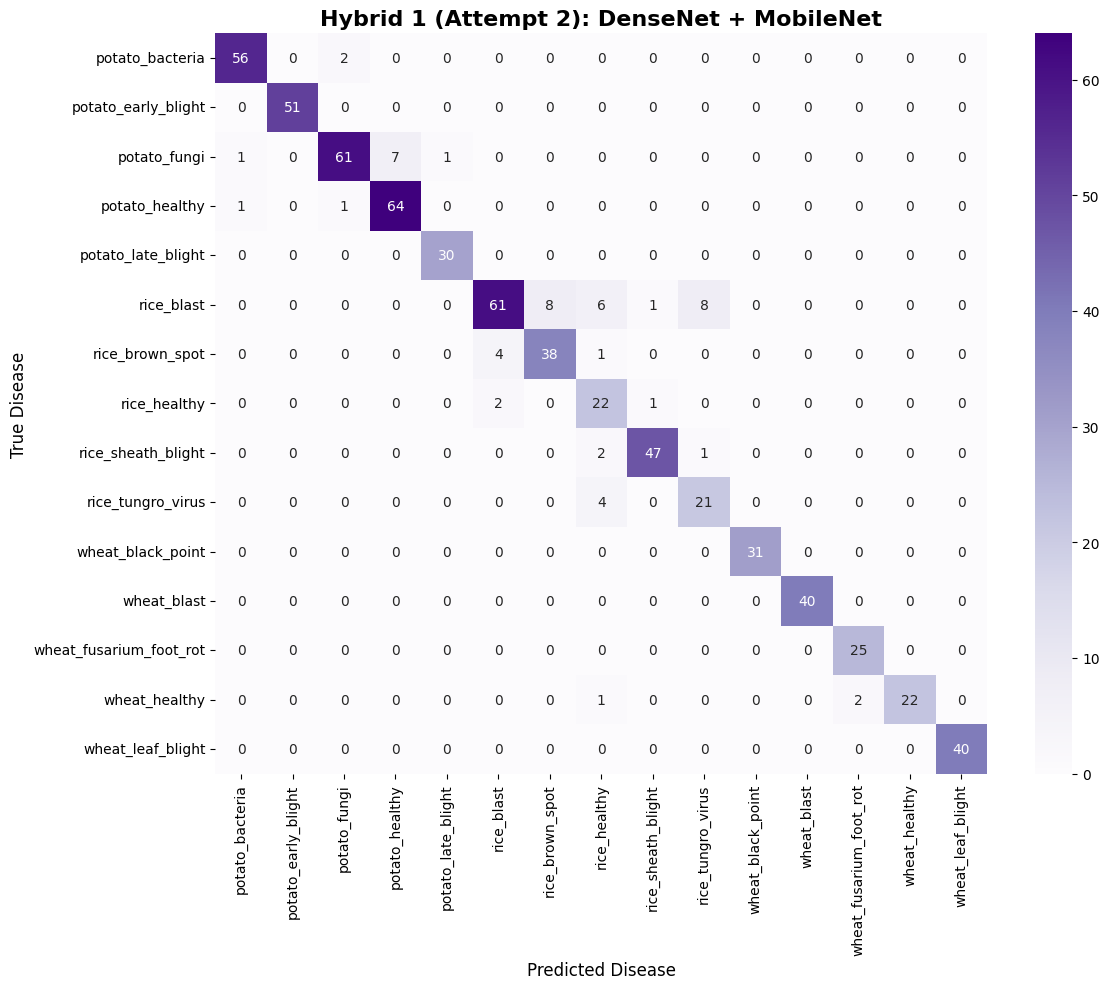

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

print("📝 Initiating Final Exam & Visuals for Hybrid 1 (Attempt 2)...")

# 1. Rebuild Test Generator with Batch Size 4
test_dir = r"D:\00_Thesis_Split\test"
IMG_SIZE = (224, 224)
TEST_BATCH_SIZE = 4 

from tensorflow.keras.preprocessing.image import ImageDataGenerator
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=TEST_BATCH_SIZE, class_mode='categorical', shuffle=False 
)

# 2. Load the absolute best fine-tuned weights from Attempt 2
filepath_hyb1_p2_attempt2 = os.path.join(r"D:\00_Thesis_Final_Models", "Hybrid1_Attempt2_Phase2_FineTuned.h5")
hybrid_model_1.load_weights(filepath_hyb1_p2_attempt2)

# 3. Get overall Accuracy on the locked-away test set
print("\n📊 Running standard evaluation on unseen Test Set...")
test_loss_hyb1, test_acc_hyb1 = hybrid_model_1.evaluate(test_generator, verbose=1)
print(f"\n🏆 Official Hybrid 1 (Attempt 2) Test Accuracy: {test_acc_hyb1 * 100:.2f}%")

# 4. Generate Predictions for the Detailed Report
print("🔍 Generating detailed predictions...")
predictions_hyb1 = hybrid_model_1.predict(test_generator, verbose=1)
y_pred_hyb1 = np.argmax(predictions_hyb1, axis=1)
y_true_hyb1 = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 5. Print Classification Report
print("\n--- Thesis Documentation: Hybrid 1 (Attempt 2) Classification Report ---")
print(classification_report(y_true_hyb1, y_pred_hyb1, target_names=class_names))

# 6. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm_hyb1 = confusion_matrix(y_true_hyb1, y_pred_hyb1)
# Using a Purple color map for the Hybrid
sns.heatmap(cm_hyb1, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title('Hybrid 1 (Attempt 2): DenseNet + MobileNet', fontsize=16, fontweight='bold')
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save to the final folder
cm_path_hyb1_attempt2 = os.path.join(r"D:\00_Thesis_Final_Models", "Hybrid1_Attempt2_Confusion_Matrix.png")
plt.savefig(cm_path_hyb1_attempt2)
print(f"✅ Confusion Matrix saved to {cm_path_hyb1_attempt2}")
plt.show()

In [4]:
import os
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, EfficientNetB0
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("🧹 1. Sledgehammering GPU Memory for Hybrid 2...")
tf.keras.backend.clear_session()

new_model_dir = r"D:\00_Thesis_Final_Models"

# ==========================================
# REBUILD GENERATORS (SAFE BATCH SIZE 4)
# ==========================================
print("♻️ 2. Spinning up Generators (Batch Size 4)...")
train_dir = r"D:\00_Thesis_Split\train"
val_dir = r"D:\00_Thesis_Split\val"
IMG_SIZE = (224, 224)
SAFE_BATCH_SIZE = 4 

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.1,   
    height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=SAFE_BATCH_SIZE, class_mode='categorical', shuffle=True 
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=SAFE_BATCH_SIZE, class_mode='categorical', shuffle=False 
)

# ==========================================
# PHASE 1: BUILD & TRAIN FROZEN HYBRID 2
# ==========================================
print("\n🧬 3. Building Hybrid 2: DenseNet121 + EfficientNetB0...")

shared_input = Input(shape=(224, 224, 3), name="hybrid2_input")

# Brain 1: DenseNet121
base_dense = DenseNet121(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_dense.layers: layer._name = layer.name + str("_dense")
base_dense.trainable = False
features_dense = GlobalAveragePooling2D()(base_dense.output)

# Brain 2: EfficientNetB0
base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_eff.layers: layer._name = layer.name + str("_eff")
base_eff.trainable = False
features_eff = GlobalAveragePooling2D()(base_eff.output)

# FUSION
combined_features = Concatenate(name="feature_fusion_2")([features_dense, features_eff])

# Master Head (The Judge)
x = BatchNormalization()(combined_features)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
hybrid_preds_2 = Dense(15, activation='softmax', name="final_output_2")(x)

hybrid_model_2 = Model(inputs=shared_input, outputs=hybrid_preds_2)
hybrid_model_2.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

filepath_hyb2_p1 = os.path.join(new_model_dir, "Hybrid2_Fresh_Phase1.h5")
checkpoint_hyb2 = ModelCheckpoint(filepath_hyb2_p1, save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1)
early_stop_hyb2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr_hyb2 = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

print(f"\n🚀 Starting Phase 1 Training. Saving to: {filepath_hyb2_p1}")
history_hyb2_p1 = hybrid_model_2.fit(
    train_generator, epochs=15, validation_data=val_generator,
    class_weight=pure_class_weights, callbacks=[checkpoint_hyb2, early_stop_hyb2, reduce_lr_hyb2], verbose=1
)

# ==========================================
# PHASE 2: FINE-TUNING THE HYBRID 2
# ==========================================
print("\n⚡ 4. Unfreezing Hybrid 2 (Fine-Tuning)...")

hybrid_model_2.load_weights(filepath_hyb2_p1)
base_dense.trainable = True
base_eff.trainable = True

hybrid_model_2.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

filepath_hyb2_p2 = os.path.join(new_model_dir, "Hybrid2_Fresh_Phase2_FineTuned.h5")
checkpoint_hyb2_fine = ModelCheckpoint(filepath_hyb2_p2, save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1)
early_stop_hyb2_fine = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print(f"\n🚀 Starting Fine-Tuning. Saving best weights to: {filepath_hyb2_p2}")
history_hyb2_p2 = hybrid_model_2.fit(
    train_generator, epochs=15, validation_data=val_generator,
    class_weight=pure_class_weights, callbacks=[checkpoint_hyb2_fine, early_stop_hyb2_fine], verbose=1
)

print("\n✅ Hybrid 2 Full Training Complete.")

🧹 1. Sledgehammering GPU Memory for Hybrid 2...
♻️ 2. Spinning up Generators (Batch Size 4)...
Found 5238 images belonging to 15 classes.
Found 650 images belonging to 15 classes.

🧬 3. Building Hybrid 2: DenseNet121 + EfficientNetB0...

🚀 Starting Phase 1 Training. Saving to: D:\00_Thesis_Final_Models\Hybrid2_Fresh_Phase1.h5
Epoch 1/15
1310/1310 [==============================] - ETA: 0s - loss: 1.7943 - accuracy: 0.4645
Epoch 1: val_accuracy improved from -inf to 0.76615, saving model to D:\00_Thesis_Final_Models\Hybrid2_Fresh_Phase1.h5
1310/1310 [==============================] - 204s 141ms/step - loss: 1.7943 - accuracy: 0.4645 - val_loss: 0.8419 - val_accuracy: 0.7662 - lr: 0.0010
Epoch 2/15
1310/1310 [==============================] - ETA: 0s - loss: 1.0634 - accuracy: 0.6157
Epoch 2: val_accuracy improved from 0.76615 to 0.82308, saving model to D:\00_Thesis_Final_Models\Hybrid2_Fresh_Phase1.h5
1310/1310 [==============================] - 176s 134ms/step - loss: 1.0634 - accurac

📝 Initiating Final Exam & Visuals for Hybrid 2 (DenseNet121 + EfficientNetB0)...
Found 663 images belonging to 15 classes.

📊 Running standard evaluation on unseen Test Set...
166/166 [==============================] - 17s 99ms/step - loss: 0.3111 - accuracy: 0.9216

🏆 Official Hybrid 2 Test Accuracy: 92.16%
🔍 Generating detailed predictions...
166/166 [==============================] - 34s 96ms/step

--- Thesis Documentation: Hybrid 2 Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       1.00      0.93      0.96        58
    potato_early_blight       1.00      1.00      1.00        51
           potato_fungi       0.93      0.94      0.94        70
         potato_healthy       0.96      0.98      0.97        66
     potato_late_blight       0.97      1.00      0.98        30
             rice_blast       0.84      0.73      0.78        84
        rice_brown_spot       0.89      0.77      0.82        43
           ri

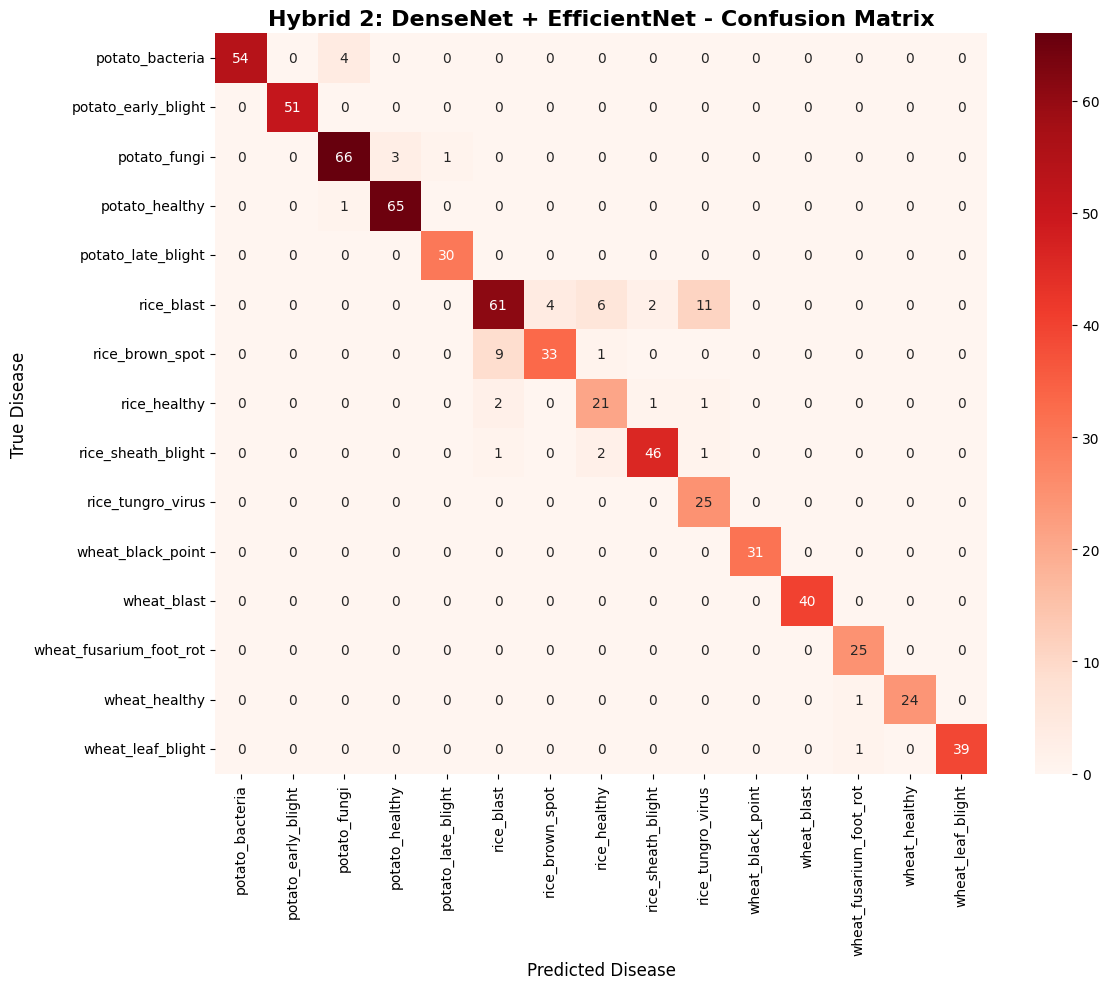

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("📝 Initiating Final Exam & Visuals for Hybrid 2 (DenseNet121 + EfficientNetB0)...")

# 1. Rebuild Test Generator with Batch Size 4
test_dir = r"D:\00_Thesis_Split\test"
IMG_SIZE = (224, 224)
TEST_BATCH_SIZE = 4 

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=TEST_BATCH_SIZE, class_mode='categorical', shuffle=False 
)

# 2. Load the absolute best fine-tuned weights for Hybrid 2
filepath_hyb2_p2 = os.path.join(r"D:\00_Thesis_Final_Models", "Hybrid2_Fresh_Phase2_FineTuned.h5")
hybrid_model_2.load_weights(filepath_hyb2_p2)

# 3. Get overall Accuracy on the locked-away test set
print("\n📊 Running standard evaluation on unseen Test Set...")
test_loss_hyb2, test_acc_hyb2 = hybrid_model_2.evaluate(test_generator, verbose=1)
print(f"\n🏆 Official Hybrid 2 Test Accuracy: {test_acc_hyb2 * 100:.2f}%")

# 4. Generate Predictions for the Detailed Report
print("🔍 Generating detailed predictions...")
predictions_hyb2 = hybrid_model_2.predict(test_generator, verbose=1)
y_pred_hyb2 = np.argmax(predictions_hyb2, axis=1)
y_true_hyb2 = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 5. Print Classification Report
print("\n--- Thesis Documentation: Hybrid 2 Classification Report ---")
print(classification_report(y_true_hyb2, y_pred_hyb2, target_names=class_names))

# 6. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm_hyb2 = confusion_matrix(y_true_hyb2, y_pred_hyb2)
# Using a Red color map to distinguish this Hybrid
sns.heatmap(cm_hyb2, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.title('Hybrid 2: DenseNet + EfficientNet - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save to the final folder
cm_path_hyb2 = os.path.join(r"D:\00_Thesis_Final_Models", "Hybrid2_Fresh_Confusion_Matrix.png")
plt.savefig(cm_path_hyb2)
print(f"✅ Confusion Matrix saved to {cm_path_hyb2}")
plt.show()

In [2]:
import os
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("🧹 1. Sledgehammering GPU Memory for Hybrid 3...")
tf.keras.backend.clear_session()

new_model_dir = r"D:\00_Thesis_Final_Models"

# ==========================================
# REBUILD GENERATORS (SAFE BATCH SIZE 4)
# ==========================================
print("♻️ 2. Spinning up Generators (Batch Size 4)...")
train_dir = r"D:\00_Thesis_Split\train"
val_dir = r"D:\00_Thesis_Split\val"
IMG_SIZE = (224, 224)
SAFE_BATCH_SIZE = 4 

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.1,   
    height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=SAFE_BATCH_SIZE, class_mode='categorical', shuffle=True 
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=SAFE_BATCH_SIZE, class_mode='categorical', shuffle=False 
)

# ==========================================
# PHASE 1: BUILD & TRAIN FROZEN HYBRID 3
# ==========================================
print("\n🧬 3. Building Hybrid 3: MobileNetV2 + EfficientNetB0...")

shared_input = Input(shape=(224, 224, 3), name="hybrid3_input")

# Brain 1: MobileNetV2
base_mob = MobileNetV2(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_mob.layers: layer._name = layer.name + str("_mob")
base_mob.trainable = False
features_mob = GlobalAveragePooling2D()(base_mob.output)

# Brain 2: EfficientNetB0
base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_eff.layers: layer._name = layer.name + str("_eff")
base_eff.trainable = False
features_eff = GlobalAveragePooling2D()(base_eff.output)

# FUSION
combined_features = Concatenate(name="feature_fusion_3")([features_mob, features_eff])

# Master Head (The Judge)
x = BatchNormalization()(combined_features)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
hybrid_preds_3 = Dense(15, activation='softmax', name="final_output_3")(x)

hybrid_model_3 = Model(inputs=shared_input, outputs=hybrid_preds_3)
hybrid_model_3.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

filepath_hyb3_p1 = os.path.join(new_model_dir, "Hybrid3_Fresh_Phase1.h5")
checkpoint_hyb3 = ModelCheckpoint(filepath_hyb3_p1, save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1)
early_stop_hyb3 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr_hyb3 = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

print(f"\n🚀 Starting Phase 1 Training. Saving to: {filepath_hyb3_p1}")
history_hyb3_p1 = hybrid_model_3.fit(
    train_generator, epochs=15, validation_data=val_generator,
    class_weight=pure_class_weights, callbacks=[checkpoint_hyb3, early_stop_hyb3, reduce_lr_hyb3], verbose=1
)

# ==========================================
# PHASE 2: FINE-TUNING THE HYBRID 3
# ==========================================
print("\n⚡ 4. Unfreezing Hybrid 3 (Fine-Tuning)...")

hybrid_model_3.load_weights(filepath_hyb3_p1)
base_mob.trainable = True
base_eff.trainable = True

hybrid_model_3.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

filepath_hyb3_p2 = os.path.join(new_model_dir, "Hybrid3_Fresh_Phase2_FineTuned.h5")
checkpoint_hyb3_fine = ModelCheckpoint(filepath_hyb3_p2, save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1)
early_stop_hyb3_fine = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print(f"\n🚀 Starting Fine-Tuning. Saving best weights to: {filepath_hyb3_p2}")
history_hyb3_p2 = hybrid_model_3.fit(
    train_generator, epochs=15, validation_data=val_generator,
    class_weight=pure_class_weights, callbacks=[checkpoint_hyb3_fine, early_stop_hyb3_fine], verbose=1
)

print("\n✅ Hybrid 3 Full Training Complete.")

🧹 1. Sledgehammering GPU Memory for Hybrid 3...
♻️ 2. Spinning up Generators (Batch Size 4)...
Found 5238 images belonging to 15 classes.
Found 650 images belonging to 15 classes.

🧬 3. Building Hybrid 3: MobileNetV2 + EfficientNetB0...

🚀 Starting Phase 1 Training. Saving to: D:\00_Thesis_Final_Models\Hybrid3_Fresh_Phase1.h5
Epoch 1/15
1310/1310 [==============================] - ETA: 0s - loss: 1.8738 - accuracy: 0.4710
Epoch 1: val_accuracy improved from -inf to 0.76769, saving model to D:\00_Thesis_Final_Models\Hybrid3_Fresh_Phase1.h5
1310/1310 [==============================] - 215s 150ms/step - loss: 1.8738 - accuracy: 0.4710 - val_loss: 0.6566 - val_accuracy: 0.7677 - lr: 0.0010
Epoch 2/15
1310/1310 [==============================] - ETA: 0s - loss: 1.2039 - accuracy: 0.5920
Epoch 2: val_accuracy did not improve from 0.76769
1310/1310 [==============================] - 188s 143ms/step - loss: 1.2039 - accuracy: 0.5920 - val_loss: 0.8385 - val_accuracy: 0.7215 - lr: 0.0010
Epoch 

📝 Initiating Final Exam & Visuals for Hybrid 3 (MobileNet + EfficientNet)...
Found 663 images belonging to 15 classes.

📊 Running standard evaluation on unseen Test Set...
166/166 [==============================] - 12s 71ms/step - loss: 0.5745 - accuracy: 0.8431

🏆 Official Hybrid 3 Test Accuracy: 84.31%
🔍 Generating detailed predictions...
166/166 [==============================] - 10s 44ms/step

--- Thesis Documentation: Hybrid 3 Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       0.89      0.93      0.91        58
    potato_early_blight       0.98      0.98      0.98        51
           potato_fungi       0.90      0.80      0.85        70
         potato_healthy       0.88      0.92      0.90        66
     potato_late_blight       0.94      0.97      0.95        30
             rice_blast       0.75      0.52      0.62        84
        rice_brown_spot       0.71      0.79      0.75        43
           rice_h

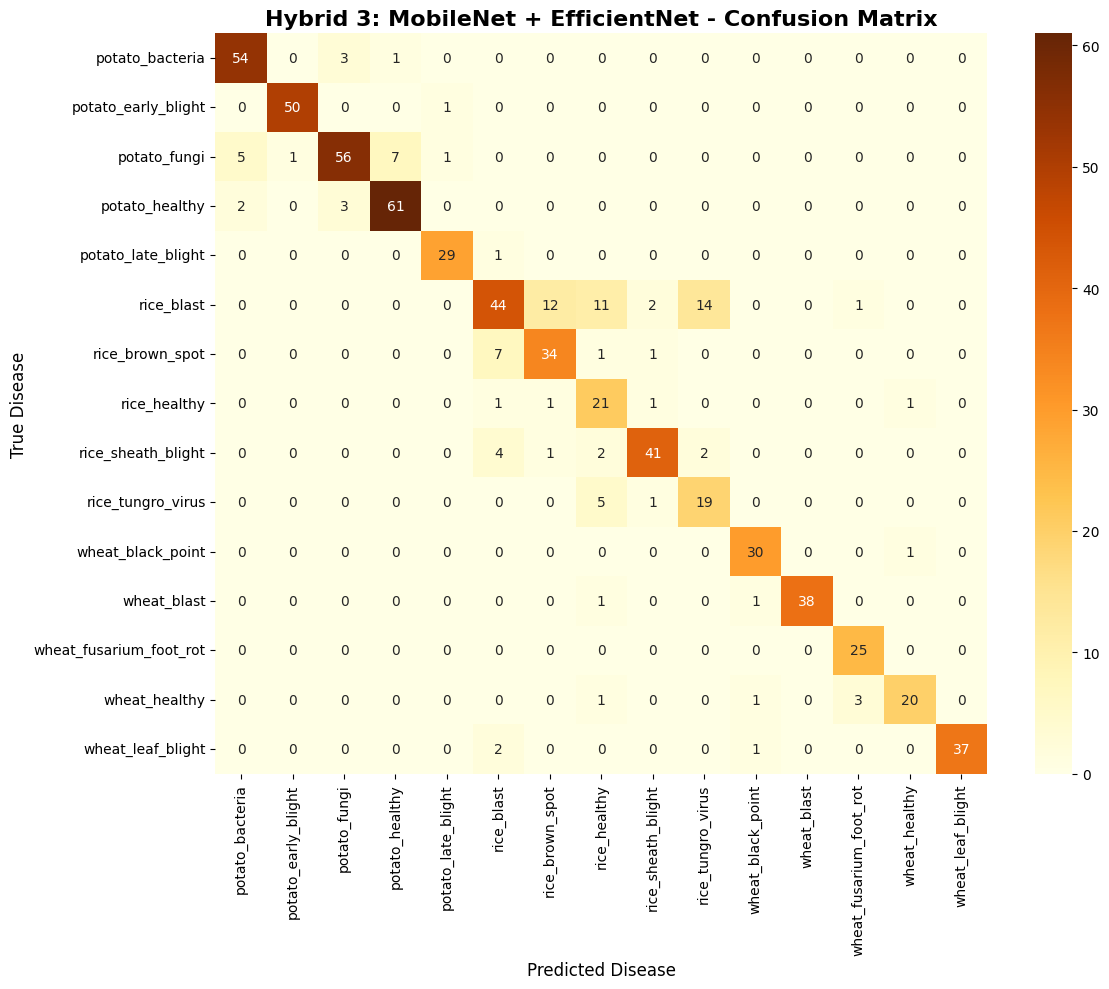

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("📝 Initiating Final Exam & Visuals for Hybrid 3 (MobileNet + EfficientNet)...")

# 1. Rebuild Test Generator with Batch Size 4
test_dir = r"D:\00_Thesis_Split\test"
IMG_SIZE = (224, 224)
TEST_BATCH_SIZE = 4 

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=TEST_BATCH_SIZE, class_mode='categorical', shuffle=False 
)


# 2. Load the absolute best fine-tuned weights for Hybrid 3
filepath_hyb3_p2 = os.path.join(r"D:\00_Thesis_Final_Models", "Hybrid3_Fresh_Phase2_FineTuned.h5")
hybrid_model_3.load_weights(filepath_hyb3_p2)



# 3. Get overall Accuracy on the locked-away test set
print("\n📊 Running standard evaluation on unseen Test Set...")
test_loss_hyb3, test_acc_hyb3 = hybrid_model_3.evaluate(test_generator, verbose=1)
print(f"\n🏆 Official Hybrid 3 Test Accuracy: {test_acc_hyb3 * 100:.2f}%")

# 4. Generate Predictions for the Detailed Report
print("🔍 Generating detailed predictions...")
predictions_hyb3 = hybrid_model_3.predict(test_generator, verbose=1)
y_pred_hyb3 = np.argmax(predictions_hyb3, axis=1)
y_true_hyb3 = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 5. Print Classification Report
print("\n--- Thesis Documentation: Hybrid 3 Classification Report ---")
print(classification_report(y_true_hyb3, y_pred_hyb3, target_names=class_names))

# 6. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm_hyb3 = confusion_matrix(y_true_hyb3, y_pred_hyb3)
# Using a Yellow/Orange/Brown color map for the final Hybrid
sns.heatmap(cm_hyb3, annot=True, fmt='d', cmap='YlOrBr', xticklabels=class_names, yticklabels=class_names)
plt.title('Hybrid 3: MobileNet + EfficientNet - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save to the final folder
cm_path_hyb3 = os.path.join(r"D:\00_Thesis_Final_Models", "Hybrid3_Fresh_Confusion_Matrix.png")
plt.savefig(cm_path_hyb3)
print(f"✅ Confusion Matrix saved to {cm_path_hyb3}")
plt.show()

📊 Starting Final Evaluation & Plotting Script...
Found 663 images belonging to 15 classes.

🔍 Evaluating Hybrid 1...
166/166 [==============================] - 18s 75ms/step

🔍 Evaluating Hybrid 2...
166/166 [==============================] - 19s 77ms/step

🔍 Evaluating Hybrid 3...
166/166 [==============================] - 16s 69ms/step

🎨 Generating Visuals...


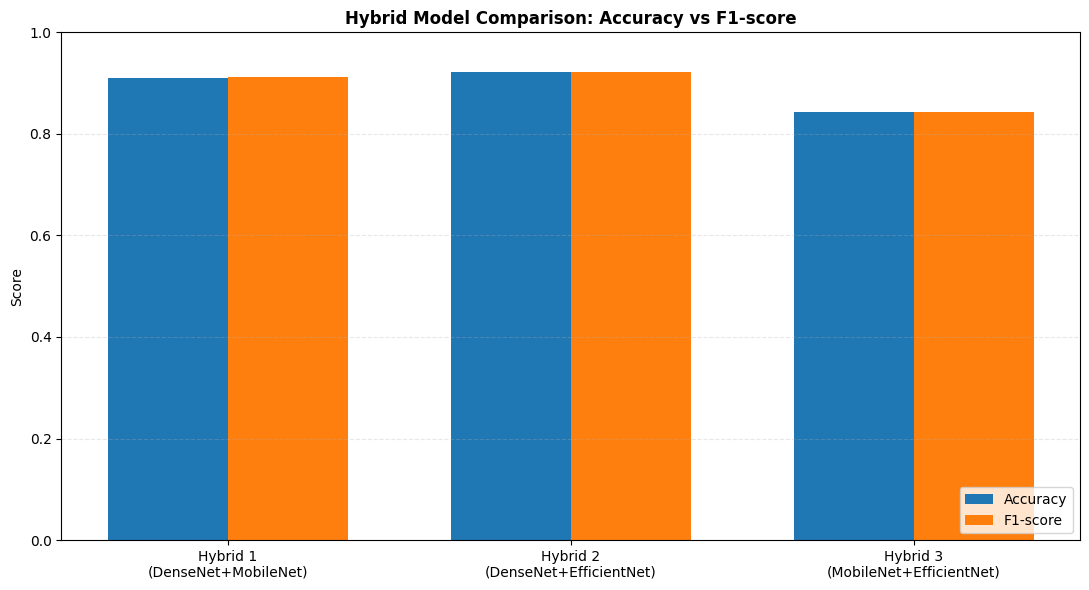

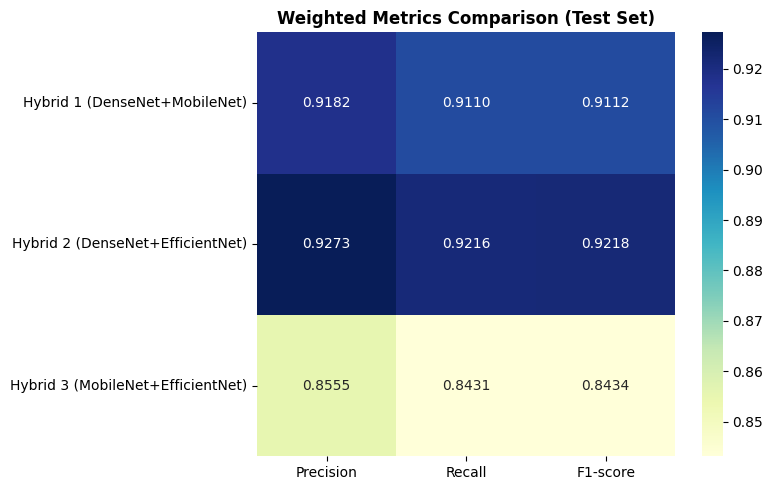

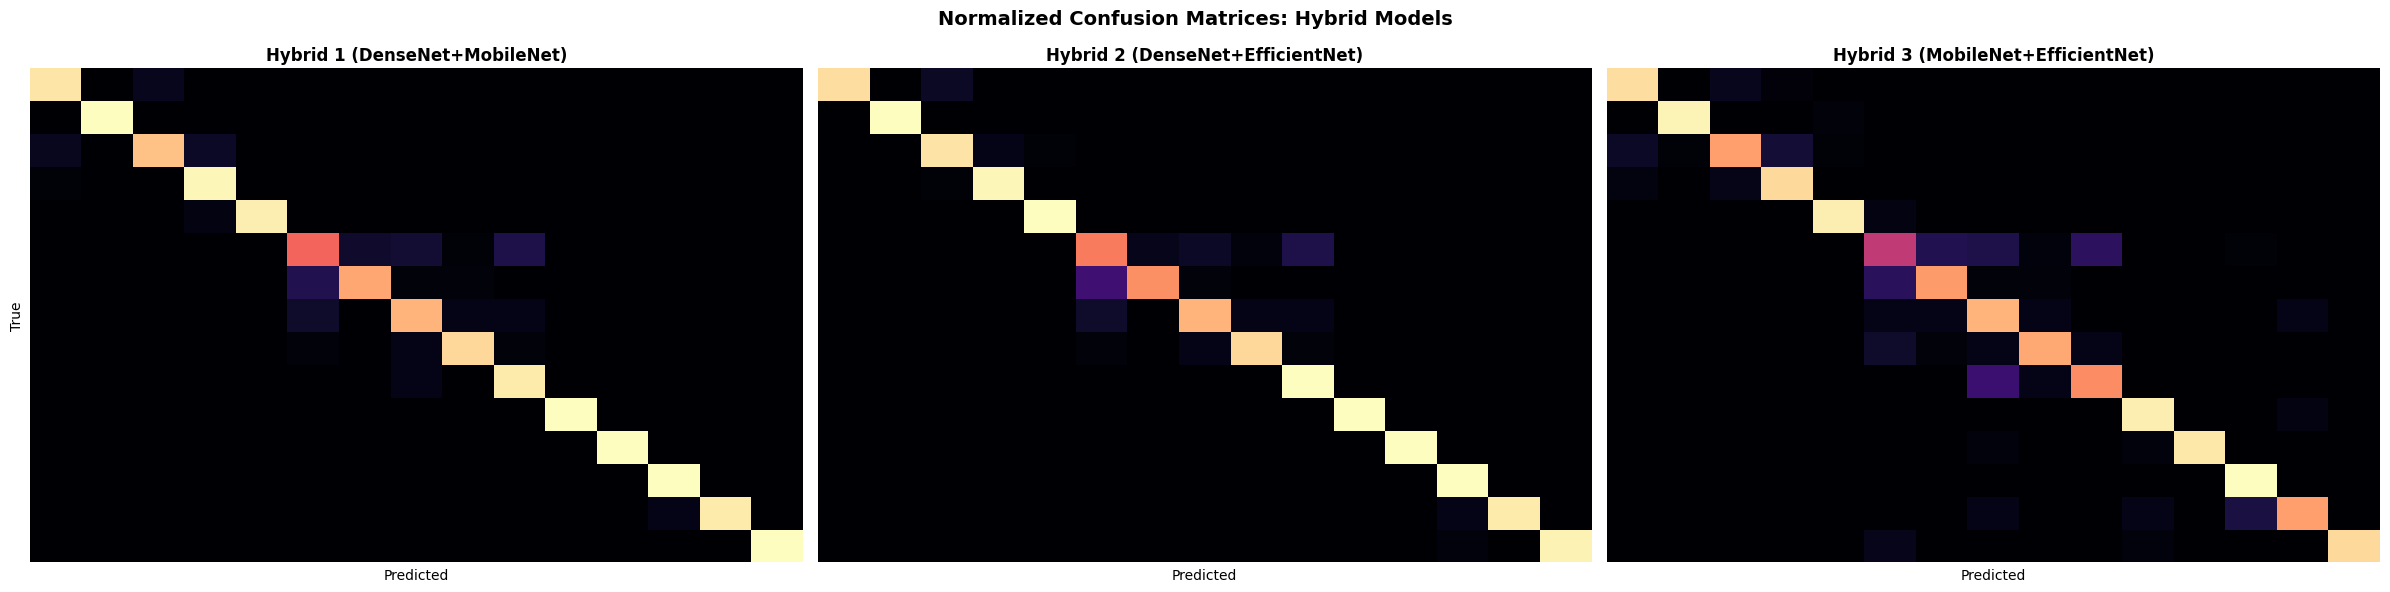


🏁 Final Summary (sorted by Accuracy):
- Hybrid 2 (DenseNet+EfficientNet) | Acc: 0.9216 | F1: 0.9218 | Prec: 0.9273 | Rec: 0.9216
- Hybrid 1 (DenseNet+MobileNet) | Acc: 0.9110 | F1: 0.9112 | Prec: 0.9182 | Rec: 0.9110
- Hybrid 3 (MobileNet+EfficientNet) | Acc: 0.8431 | F1: 0.8434 | Prec: 0.8555 | Rec: 0.8431


In [3]:
import os
import gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, MobileNetV2, EfficientNetB0
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("📊 Starting Final Evaluation & Plotting Script...")

# ==========================================
# 0. ENABLE GPU MEMORY GROWTH (CRASH PREVENTION)
# ==========================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except:
        pass

# ==========================================
# 1. SETUP GENERATORS
# ==========================================
test_dir = r"D:\00_Thesis_Split\test"
models_dir = r"D:\00_Thesis_Final_Models"
TEST_BATCH_SIZE = 4 

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=TEST_BATCH_SIZE, class_mode='categorical', shuffle=False
)

class_names = list(test_generator.class_indices.keys())
y_true = test_generator.classes

# Arrays to hold results for the plots
results = []
cms = []

# Helper function to build the top layers
def build_top_layers(combined_features, output_name):
    x = BatchNormalization()(combined_features)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    return Dense(15, activation='softmax', name=output_name)(x)

# ==========================================
# 2. TEST HYBRID 1 (DenseNet + MobileNet)
# ==========================================
print("\n🔍 Evaluating Hybrid 1...")
tf.keras.backend.clear_session()
shared_input = Input(shape=(224, 224, 3), name="hybrid1_input")

base_dense = DenseNet121(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_dense.layers: layer._name = layer.name + "_dense"

base_mob = MobileNetV2(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_mob.layers: layer._name = layer.name + "_mob"

combined_1 = Concatenate(name="feature_fusion_1")([GlobalAveragePooling2D()(base_dense.output), GlobalAveragePooling2D()(base_mob.output)])
model_1 = Model(inputs=shared_input, outputs=build_top_layers(combined_1, "final_output_1"))

model_1.compile(loss='categorical_crossentropy', metrics=['accuracy'])
model_1.load_weights(os.path.join(models_dir, "Hybrid1_Fresh_Phase2_FineTuned.h5"), by_name=True)

# Evaluate and Predict
test_generator.reset()
loss1, acc1 = model_1.evaluate(test_generator, verbose=0)
test_generator.reset()
probs1 = model_1.predict(test_generator, verbose=1)
y_pred1 = np.argmax(probs1, axis=1)

# Store Metrics
report1 = classification_report(y_true, y_pred1, output_dict=True, zero_division=0)
cms.append(confusion_matrix(y_true, y_pred1))
results.append({"name": "Hybrid 1\n(DenseNet+MobileNet)", "accuracy": acc1, "f1": report1["weighted avg"]["f1-score"], "precision": report1["weighted avg"]["precision"], "recall": report1["weighted avg"]["recall"]})

# Aggressive Cleanup
del model_1, probs1
tf.keras.backend.clear_session()
gc.collect()

# ==========================================
# 3. TEST HYBRID 2 (DenseNet + EfficientNet)
# ==========================================
print("\n🔍 Evaluating Hybrid 2...")
shared_input = Input(shape=(224, 224, 3), name="hybrid2_input")

base_dense = DenseNet121(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_dense.layers: layer._name = layer.name + "_dense"

base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_eff.layers: layer._name = layer.name + "_eff"

combined_2 = Concatenate(name="feature_fusion_2")([GlobalAveragePooling2D()(base_dense.output), GlobalAveragePooling2D()(base_eff.output)])
model_2 = Model(inputs=shared_input, outputs=build_top_layers(combined_2, "final_output_2"))

model_2.compile(loss='categorical_crossentropy', metrics=['accuracy'])
model_2.load_weights(os.path.join(models_dir, "Hybrid2_Fresh_Phase2_FineTuned.h5"), by_name=True)

# Evaluate and Predict
test_generator.reset()
loss2, acc2 = model_2.evaluate(test_generator, verbose=0)
test_generator.reset()
probs2 = model_2.predict(test_generator, verbose=1)
y_pred2 = np.argmax(probs2, axis=1)

# Store Metrics
report2 = classification_report(y_true, y_pred2, output_dict=True, zero_division=0)
cms.append(confusion_matrix(y_true, y_pred2))
results.append({"name": "Hybrid 2\n(DenseNet+EfficientNet)", "accuracy": acc2, "f1": report2["weighted avg"]["f1-score"], "precision": report2["weighted avg"]["precision"], "recall": report2["weighted avg"]["recall"]})

# Aggressive Cleanup
del model_2, probs2
tf.keras.backend.clear_session()
gc.collect()

# ==========================================
# 4. TEST HYBRID 3 (MobileNet + EfficientNet)
# ==========================================
print("\n🔍 Evaluating Hybrid 3...")
shared_input = Input(shape=(224, 224, 3), name="hybrid3_input")

base_mob = MobileNetV2(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_mob.layers: layer._name = layer.name + "_mob"

base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_eff.layers: layer._name = layer.name + "_eff"

combined_3 = Concatenate(name="feature_fusion_3")([GlobalAveragePooling2D()(base_mob.output), GlobalAveragePooling2D()(base_eff.output)])
model_3 = Model(inputs=shared_input, outputs=build_top_layers(combined_3, "final_output_3"))

model_3.compile(loss='categorical_crossentropy', metrics=['accuracy'])
model_3.load_weights(os.path.join(models_dir, "Hybrid3_Fresh_Phase2_FineTuned.h5"), by_name=True)

# Evaluate and Predict
test_generator.reset()
loss3, acc3 = model_3.evaluate(test_generator, verbose=0)
test_generator.reset()
probs3 = model_3.predict(test_generator, verbose=1)
y_pred3 = np.argmax(probs3, axis=1)

# Store Metrics
report3 = classification_report(y_true, y_pred3, output_dict=True, zero_division=0)
cms.append(confusion_matrix(y_true, y_pred3))
results.append({"name": "Hybrid 3\n(MobileNet+EfficientNet)", "accuracy": acc3, "f1": report3["weighted avg"]["f1-score"], "precision": report3["weighted avg"]["precision"], "recall": report3["weighted avg"]["recall"]})

# Aggressive Cleanup
del model_3, probs3
tf.keras.backend.clear_session()
gc.collect()


# ==========================================
# 5. GENERATE VISUALS
# ==========================================
print("\n🎨 Generating Visuals...")
names = [r["name"] for r in results]
accs = np.array([r["accuracy"] for r in results])
f1s = np.array([r["f1"] for r in results])
precs = np.array([r["precision"] for r in results])
recs = np.array([r["recall"] for r in results])

# VISUAL A: ACCURACY + F1 BAR CHART
x = np.arange(len(names))
w = 0.35

plt.figure(figsize=(11, 6))
plt.bar(x - w/2, accs, width=w, label="Accuracy")
plt.bar(x + w/2, f1s, width=w, label="F1-score")
plt.xticks(x, names)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Hybrid Model Comparison: Accuracy vs F1-score", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# VISUAL B: PRECISION/RECALL/F1 HEATMAP
metric_matrix = np.vstack([precs, recs, f1s]).T
plt.figure(figsize=(8, 5))
sns.heatmap(metric_matrix, annot=True, fmt=".4f", cmap="YlGnBu", xticklabels=["Precision", "Recall", "F1-score"], yticklabels=[n.replace('\n', ' ') for n in names])
plt.title("Weighted Metrics Comparison (Test Set)", fontweight="bold")
plt.tight_layout()
plt.show()

# VISUAL C: NORMALIZED CONFUSION MATRICES
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
for i, (name, cm) in enumerate(zip(names, cms)):
    cm_norm = cm.astype(np.float32) / np.clip(cm.sum(axis=1, keepdims=True), a_min=1, a_max=None)
    sns.heatmap(cm_norm, ax=axes[i], cmap="magma", cbar=False, xticklabels=False, yticklabels=False)
    axes[i].set_title(name.replace("\n", " "), fontweight="bold")
    axes[i].set_xlabel("Predicted")
    if i == 0: axes[i].set_ylabel("True")

plt.suptitle("Normalized Confusion Matrices: Hybrid Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# FINAL TEXT SUMMARY
print("\n🏁 Final Summary (sorted by Accuracy):")
for r in sorted(results, key=lambda z: z["accuracy"], reverse=True):
    print(f"- {r['name'].replace(chr(10), ' ')} | Acc: {r['accuracy']:.4f} | F1: {r['f1']:.4f} | Prec: {r['precision']:.4f} | Rec: {r['recall']:.4f}")